In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats

from ipywidgets import interact
from noshow.config import CLINIC_CONFIG
from pathlib import Path
from noshow.features.appointment_features import (
    add_appointments_last_days,
    add_appointments_same_day,
    add_days_since_created,
    add_days_since_last_appointment,
    add_minutes_early,
    add_time_features,
)
from noshow.features.no_show_features import prev_no_show_features
from noshow.features.patient_features import add_patient_features
from noshow.preprocessing.load_data import (
    load_appointment_csv,
    process_appointments,
    process_postal_codes,
)
from noshow.features.feature_pipeline import create_features
from noshow.visualisation.features_plots import feature_barplot, feature_scatter
from noshow.preprocessing.geo import haversine_distance

In [2]:
appointments_df = load_appointment_csv("../data/raw/poliafspraken_no_show.csv")
appointments_df = process_appointments(appointments_df, CLINIC_CONFIG)

appointments_df["no_show"] = "show"

# Setting 'no_show' to 'no_show' for rows with status "Is niet voldaan" and cancelationReason_code "N" or "NF"
appointments_df.loc[
    (appointments_df["status"] == "Is niet voldaan") & 
    (appointments_df["cancelationReason_code"].isin(["N", "NF"])),
    "no_show"
] = "no_show"

# Replacing 'no_show' with 1 and 'show' with 0
appointments_df["no_show"] = (
    appointments_df["no_show"].replace({"no_show": "1", "show": "0"}).astype(int)
)


/home/jovyan/No_Show/src/noshow/preprocessing/load_data.py:52: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  appointments_df = pd.read_csv(


before start dates NaT onbekend 157514


In [3]:
print(appointments_df.columns)

Index(['APP_ID', 'wat_id?', 'hoofdagenda', 'hoofdagenda_id', 'subagenda_id',
       'specialty_code', 'soort_consult', 'afspraak_code', 'end', 'arrival',
       'created', 'minutesDuration', 'status', 'status_code_original',
       'cancelationReason_code', 'cancelationReason_display', 'BIRTH_YEAR',
       'address_postalCodeNumbersNL', 'name', 'description', 'ziekenhuis',
       'soort_cons', 'ConsultTypeDescription', 'geen_idee', 'gender',
       'geen_id', 'no_show'],
      dtype='object')


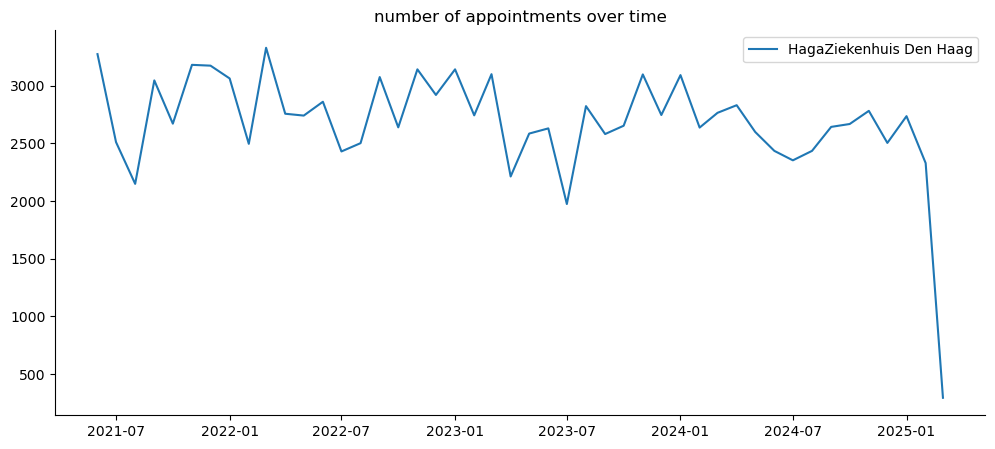

In [4]:
no_show_over_time = appointments_df.copy().reset_index()
no_show_over_time["start"] = (
    no_show_over_time["start"].dt.to_period("M").dt.to_timestamp()
)
no_show_over_time = no_show_over_time.groupby(["ziekenhuis", "start"])["no_show"].count()

fig, ax = plt.subplots(figsize=(12, 5))
for idx in no_show_over_time.index.unique(level="ziekenhuis"):
    ax.plot(
        no_show_over_time.loc[idx].index,
        no_show_over_time.loc[idx],
        label=idx,
    )
ax.legend()
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
ax.set_title("number of appointments over time")

plt.show()

In [8]:
appointments_features = appointments_df
appointments_features = prev_no_show_features(appointments_df)
appointments_features = add_appointments_same_day(appointments_features)
appointments_features = add_days_since_last_appointment(appointments_df)

appointments_features = add_days_since_created(appointments_features)
appointments_features = add_appointments_last_days(appointments_df)
appointments_features = add_minutes_early(appointments_df)
appointments_features = add_time_features(appointments_df)
appointments_features = add_patient_features(appointments_df)





KeyError: 'earlier_appointments'

In [ ]:
feature_scatter(appointments_features, "days_since_created")
plt.show()

In [ ]:
print(appointments_features['no_show'].unique())

In [ ]:
bin_edges = [0,3,7,14,21,31]
bin_labels = ['0-3','4-7','8-14','15-21','21-31']

appointments_features['days_since_bins'] = pd.cut(appointments_features['days_since_created'],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True
)

In [ ]:
feature_scatter(appointments_features, "days_since_bins")
plt.show()

In [ ]:
test = appointments_features['minutesDuration'].value_counts()
print(test)

In [ ]:
appointments_features = add_appointments_same_day(appointments_features)
test = appointments_features['appointments_same_day'].value_counts()
print(test)

In [ ]:
test = appointments_features[appointments_features.groupby("afspraak_code")['afspraak_code'].transform('count') > 50]

ax = feature_barplot(
    test,
    "afspraak_code",
    feature_name="afspraak_code",
)
plt.tight_layout()
plt.show()

In [ ]:
appointments_features["no_show"] = (
        appointments_features["no_show"].replace({"no_show": "1", "show": "0"}).astype(int)
    )


In [ ]:

subset = appointments_features[appointments_features['minutesDuration'] == 10]

count = subset['no_show'].sum()
total_app = len(subset)

no_show_perc = (count / total_app) * 100 if total_app > 0 else 0

print(total_app)
print(no_show_perc)


In [ ]:
appoints_dur = appointments_features[appointments_features['minutesDuration'] == 20]
#appoints_dur = appoints_dur[appoints_dur['appointments_same_day'] > 1]

count = appoints_dur['no_show'].sum()
total_app = len(appoints_dur)

no_show_perc = (count / total_app) * 100 if total_app > 0 else 0

print(total_app)
print(no_show_perc)

In [ ]:
appoints_dur = appointments_features[appointments_features['appointments_same_day'] > 1]

count = appoints_dur['no_show'].sum()
total_app = len(appoints_dur)

no_show_perc = (count / total_app) * 100 if total_app > 0 else 0

print(total_app)
print(no_show_perc)

In [ ]:
appoints_dur = appointments_features[appointments_features['appointments_same_day'] == 2]
total_app = len(appoints_dur)
print(total_app)

In [ ]:
appoints_dur = appointments_features[appointments_features['appointments_same_day'] == 2]
appoints_dur['date'] = pd.to_datetime(appoints_dur.index.get_level_values('start'), unit='s').date
appoints_dur = appoints_dur.sort_values(['pseudo_id', 'date', 'start'])

appoints_dur['position'] = appoints_dur.groupby(['pseudo_id', 'date']).cumcount()

#print(appoints_dur[['date', 'position']].head(10))

pivoted = appoints_dur.pivot_table(index=['pseudo_id', 'date'],
                                   columns='position',
                                   values='no_show',
                                   aggfunc='first')

pivoted.columns = ['first_no_show', 'second']

print(pivoted)

results = pivoted.value_counts().reset_index(name='count')

results['percent'] = results['count'] / results['count'].sum() * 100

print(results)

In [ ]:
feature_scatter(appointments_features, "prev_minutes_early")
plt.show()